(3, 66210255)


/tmp/ipykernel_1047785/4001754952.py:98: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  W = cwt(x, ricker, widths)        # shape: (n_scales, N)


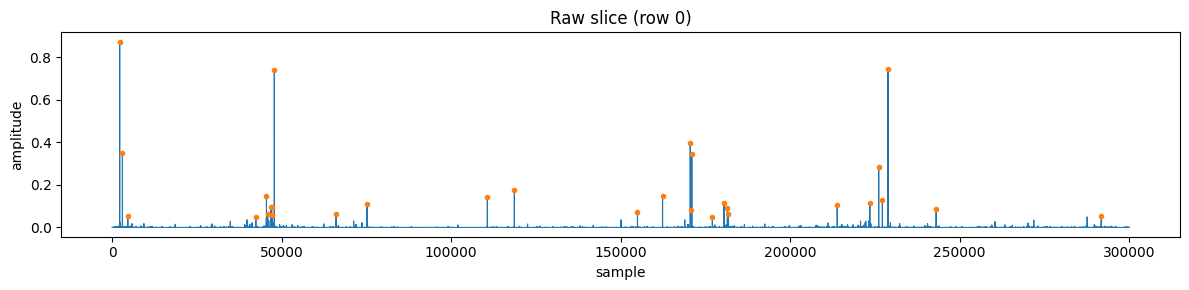

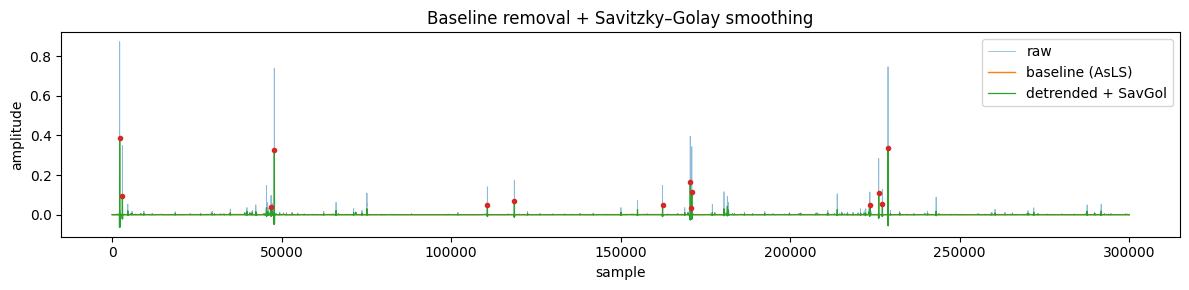

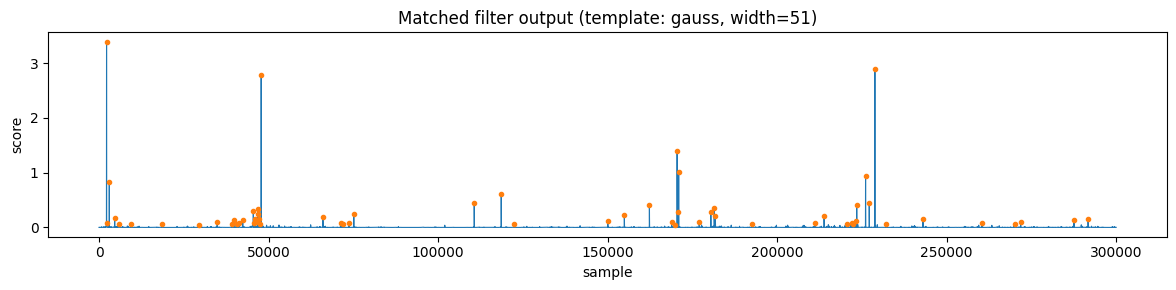

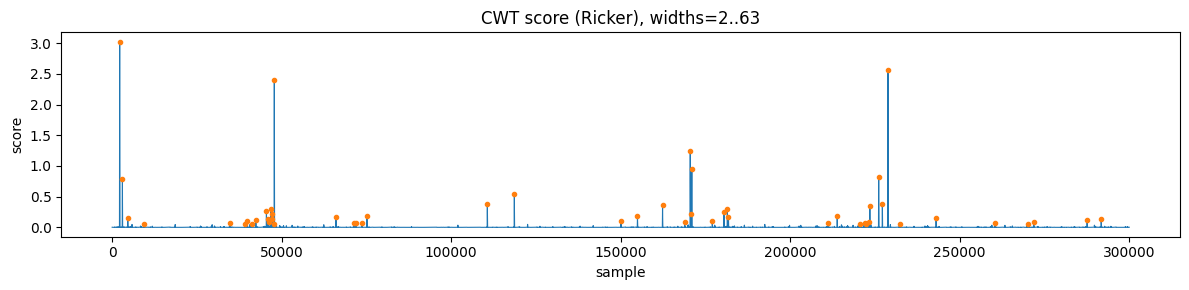

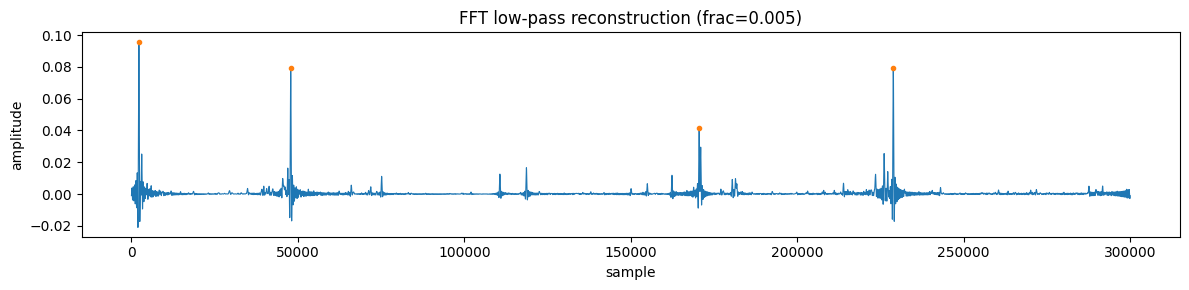

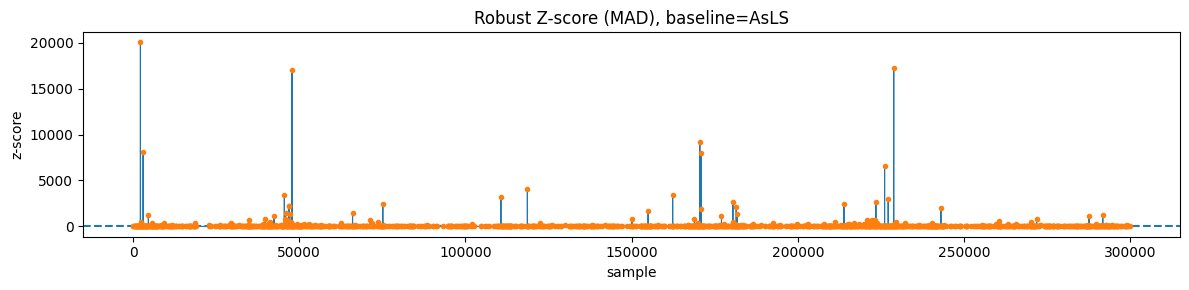

In [12]:
# ============================ CONFIG ============================
# Required: X is your numpy array of shape (3, N) with values in [0, 1]
# Example stub (delete once you plug your own X):
import numpy as np
# X = np.random.rand(3, 3_000_000)  # <-- replace with your real array
X = np.load('/home/jovyan/shares/SR003.nfs2/caduseus_artem/tss_polya/NC_060944.1-chromosome-tss_polya_21bp-100k-forward.npy')
print(X.shape)

SLICE_START = 477_000          # inclusive index into row 0
SLICE_LEN   = 300_000             # number of samples to visualize
FS          = None                # sampling rate in Hz (None => x-axis in samples)

# Baseline + smoothing
ASLS_LAMBDA = 1e6                 # smoothness penalty
ASLS_P      = 0.01                # asymmetry (0..1), smaller => flatter baseline
ASLS_ITER   = 10
SG_WINDOW   = 101                 # must be odd; will be auto-adjusted if needed
SG_POLY     = 3

# Matched filter
MF_WIDTH    = 51                  # odd length in samples
MF_SHAPE    = "gauss"             # 'gauss' | 'hann' | 'exp'

# CWT
import numpy as np
CWT_WIDTHS  = np.arange(2, 64)    # scales ~ half-widths (samples)

# FFT low-pass
LP_FRAC     = 0.005                 # keep lowest 10% of rFFT bins (rough low-pass)

# Robust Z-score
ZSCORE_USE_BASELINE = True        # use AsLS baseline if available
ZSCORE_THR  = 4.0                 # mark peaks above this z-score

# Peak picking (used on each transform’s output)
from scipy.signal import find_peaks
PK_PROM     = 0.05
PK_DIST     = 50
PK_HEIGHT   = None

SHOW_PEAKS  = True                # toggle peak markers on plots
DO_SPARSE_DECONV = False          # set True to run L1/FISTA (slower)

# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, fftconvolve, ricker, cwt, find_peaks
from scipy import sparse
from scipy.sparse.linalg import spsolve

# ----------------------- Utilities -----------------------------
def take_slice_row0(X, start, length):
    assert X.ndim == 2 and X.shape[0] == 3, "X must be shape (3, N)"
    N = X.shape[1]
    assert 0 <= start < N, "SLICE_START out of range"
    end = min(start + length, N)
    return X[1, start:end].astype(float, copy=False)

def asls_baseline(y, lam=1e6, p=0.01, niter=10):
    """Eilers & Boelens asymmetric least squares baseline (sparse, fast)."""
    N = len(y)
    D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(N - 2, N))
    w = np.ones(N)
    for _ in range(niter):
        W = sparse.diags(w, 0, shape=(N, N))
        Z = W + lam * (D.T @ D)
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

def ensure_odd(n):
    return int(n) if int(n) % 2 == 1 else int(n) + 1

def build_template(width, shape="gauss"):
    L = ensure_odd(width)
    if shape == "gauss":
        t = np.linspace(-2, 2, L)
        h = np.exp(-0.5 * (t ** 2))          # sigma ~ 1
    elif shape == "exp":
        t = np.arange(L)
        h = np.exp(-t / max(1, L / 6))
    else:
        # Hann window as a generic smooth bump
        h = 0.5 - 0.5 * np.cos(2 * np.pi * np.arange(L) / (L - 1))
    # Normalize to unit energy for matched filtering
    h = h / np.linalg.norm(h)
    return h

def matched_filter(x, width=51, shape="gauss"):
    h = build_template(width, shape)
    # correlation via FFT (use time-reversal for correlation)
    y = fftconvolve(x, h[::-1], mode="same")
    return y

def cwt_score(x, widths):
    # Ricker (Mexican hat) emphasizes bumps; take max over scales
    W = cwt(x, ricker, widths)        # shape: (n_scales, N)
    score = np.max(W, axis=0)
    return score

def fft_lowpass(x, frac=0.1):
    X = np.fft.rfft(x)
    k = int(np.clip(frac, 0, 1) * len(X))
    X_lp = np.zeros_like(X)
    X_lp[:max(1, k)] = X[:max(1, k)]
    y = np.fft.irfft(X_lp, n=len(x))
    return y

def robust_zscore(y, baseline=None):
    if baseline is None:
        # use a crude low-pass as baseline if none provided
        baseline = fft_lowpass(y, frac=0.05)
    r = y - baseline
    med = np.median(r)
    sigma = 1.4826 * np.median(np.abs(r - med)) + 1e-12
    z = (r - med) / sigma
    return z, baseline, sigma

# ---------- Optional: L1 sparse deconvolution via FISTA ----------
def sparse_deconv_fista(y, h, lam=0.1, iters=200):
    """
    Solve min_s 0.5||h*s - y||_2^2 + lam||s||_1 via FISTA using FFT conv.
    y: signal, h: kernel (same length or much shorter)
    """
    n = len(y)
    # zero-pad kernel to length n
    hpad = np.zeros(n)
    Lh = min(len(h), n)
    hpad[:Lh] = h[:Lh]
    H = np.fft.rfft(hpad)
    Hy = np.fft.rfft(y)
    L = np.max(np.abs(H) ** 2).real + 1e-12  # Lipschitz constant

    def conv(v):
        return np.fft.irfft(np.fft.rfft(v) * H, n=n)
    def convT(v):
        # adjoint uses conj(H)
        return np.fft.irfft(np.fft.rfft(v) * np.conj(H), n=n)

    def soft(x, t):
        return np.sign(x) * np.maximum(np.abs(x) - t, 0.0)

    s = np.zeros(n)
    z = s.copy()
    t = 1.0
    step = 1.0 / L
    for _ in range(iters):
        grad = convT(conv(z) - y)          # ∇(0.5||h*z - y||^2)
        s_next = soft(z - step * grad, lam * step)
        t_next = 0.5 * (1 + np.sqrt(1 + 4 * t * t))
        z = s_next + ((t - 1) / t_next) * (s_next - s)
        s, t = s_next, t_next
    return s

# ------------------------- Main flow ----------------------------
def analyze_row0_slice(X):
    x = take_slice_row0(X, SLICE_START, SLICE_LEN)
    n = len(x)
    xs = np.arange(n) if FS is None else np.arange(n) / FS
    xlab = "sample" if FS is None else "time (s)"

    # 1) Baseline removal + Savitzky–Golay smoothing
    sg_win = min(ensure_odd(SG_WINDOW), n - (1 - (n % 2)))  # ensure <= n and odd
    try:
        base = asls_baseline(x, lam=ASLS_LAMBDA, p=ASLS_P, niter=ASLS_ITER)
    except Exception as e:
        print(f"[AsLS fallback] {e} — using FFT low-pass as baseline.")
        base = fft_lowpass(x, frac=0.02)
    x_detr = x - base
    x_sg = savgol_filter(x_detr, ensure_odd(max(5, min(sg_win, n - (1 - (n % 2))))), SG_POLY)

    # 2) Matched filter
    y_mf = matched_filter(x, width=MF_WIDTH, shape=MF_SHAPE)

    # 3) CWT score
    score_cwt = cwt_score(x, CWT_WIDTHS)

    # 4) FFT low-pass reconstruction
    y_lp = fft_lowpass(x, frac=LP_FRAC)

    # 5) Robust Z-score (MAD) on high-pass residual
    zscore, z_base, z_sigma = robust_zscore(x, baseline=(base if ZSCORE_USE_BASELINE else None))

    # 6) Optional sparse deconvolution (using same template as matched filter)
    s_sparse = None
    if DO_SPARSE_DECONV:
        h = build_template(MF_WIDTH, MF_SHAPE)
        s_sparse = sparse_deconv_fista(x, h, lam=0.1, iters=200)

    # Peak picking on each representation
    peaks = {}
    if SHOW_PEAKS:
        peaks["raw"]     = find_peaks(x,        prominence=PK_PROM, distance=PK_DIST, height=PK_HEIGHT)[0]
        peaks["detr+sg"] = find_peaks(x_sg,     prominence=PK_PROM, distance=PK_DIST, height=PK_HEIGHT)[0]
        peaks["matched"] = find_peaks(y_mf,     prominence=PK_PROM, distance=PK_DIST, height=PK_HEIGHT)[0]
        peaks["cwt"]     = find_peaks(score_cwt, prominence=PK_PROM, distance=PK_DIST, height=PK_HEIGHT)[0]
        peaks["lowpass"] = find_peaks(y_lp,     prominence=PK_PROM, distance=PK_DIST, height=PK_HEIGHT)[0]
        peaks["zscore"]  = find_peaks(zscore,   height=ZSCORE_THR, distance=PK_DIST)[0]
        if s_sparse is not None:
            peaks["sparse"] = find_peaks(s_sparse, prominence=PK_PROM, distance=PK_DIST)[0]

    # --------------------- Visualization -----------------------
    # Separate figures per transform so you can compare at full width
    plt.figure(figsize=(12, 3))
    plt.plot(xs, x, linewidth=0.8)
    if SHOW_PEAKS and len(peaks["raw"]):
        plt.plot(xs[peaks["raw"]], x[peaks["raw"]], "o", markersize=3)
    plt.title("Raw slice (row 0)")
    plt.xlabel(xlab)
    plt.ylabel("amplitude")
    plt.tight_layout()

    plt.figure(figsize=(12, 3))
    plt.plot(xs, x, linewidth=0.6, alpha=0.5, label="raw")
    plt.plot(xs, base, linewidth=1.0, label="baseline (AsLS)")
    plt.plot(xs, x_sg, linewidth=0.9, label="detrended + SavGol")
    if SHOW_PEAKS and len(peaks["detr+sg"]):
        plt.plot(xs[peaks["detr+sg"]], x_sg[peaks["detr+sg"]], "o", markersize=3)
    plt.legend(loc="best")
    plt.title("Baseline removal + Savitzky–Golay smoothing")
    plt.xlabel(xlab); plt.ylabel("amplitude"); plt.tight_layout()

    plt.figure(figsize=(12, 3))
    plt.plot(xs, y_mf, linewidth=0.8)
    if SHOW_PEAKS and len(peaks["matched"]):
        plt.plot(xs[peaks["matched"]], y_mf[peaks["matched"]], "o", markersize=3)
    plt.title(f"Matched filter output (template: {MF_SHAPE}, width={MF_WIDTH})")
    plt.xlabel(xlab); plt.ylabel("score"); plt.tight_layout()

    plt.figure(figsize=(12, 3))
    plt.plot(xs, score_cwt, linewidth=0.8)
    if SHOW_PEAKS and len(peaks["cwt"]):
        plt.plot(xs[peaks["cwt"]], score_cwt[peaks["cwt"]], "o", markersize=3)
    plt.title(f"CWT score (Ricker), widths={CWT_WIDTHS[0]}..{CWT_WIDTHS[-1]}")
    plt.xlabel(xlab); plt.ylabel("score"); plt.tight_layout()

    plt.figure(figsize=(12, 3))
    plt.plot(xs, y_lp, linewidth=0.8)
    if SHOW_PEAKS and len(peaks["lowpass"]):
        plt.plot(xs[peaks["lowpass"]], y_lp[peaks["lowpass"]], "o", markersize=3)
    plt.title(f"FFT low-pass reconstruction (frac={LP_FRAC})")
    plt.xlabel(xlab); plt.ylabel("amplitude"); plt.tight_layout()

    plt.figure(figsize=(12, 3))
    plt.plot(xs, zscore, linewidth=0.8)
    plt.axhline(ZSCORE_THR, linestyle="--")
    if SHOW_PEAKS and len(peaks["zscore"]):
        plt.plot(xs[peaks["zscore"]], zscore[peaks["zscore"]], "o", markersize=3)
    plt.title(f"Robust Z-score (MAD), baseline={'AsLS' if ZSCORE_USE_BASELINE else 'LP'}")
    plt.xlabel(xlab); plt.ylabel("z-score"); plt.tight_layout()

    if s_sparse is not None:
        plt.figure(figsize=(12, 3))
        # show impulses; stem-like effect
        plt.plot(xs, s_sparse, linewidth=0.8)
        if SHOW_PEAKS and "sparse" in peaks and len(peaks["sparse"]):
            plt.plot(xs[peaks["sparse"]], s_sparse[peaks["sparse"]], "o", markersize=3)
        plt.title("Sparse L1 deconvolution (FISTA) — recovered impulses")
        plt.xlabel(xlab); plt.ylabel("amplitude"); plt.tight_layout()

    plt.show()

    return {
        "slice": x,
        "baseline": base,
        "detr_savgol": x_sg,
        "matched": y_mf,
        "cwt_score": score_cwt,
        "lowpass": y_lp,
        "zscore": zscore,
        "zscore_sigma": z_sigma,
        "sparse_impulses": s_sparse,
        "peaks": peaks if SHOW_PEAKS else None
    }

# ---------------------- Run the analysis -----------------------
results = analyze_row0_slice(X)


In [1]:
# ======================= FFT PEAK CALLING =======================
# Input can be loaded from disk via INPUT_PATH or passed as X (shape (3, N)).
# Only FFT low-pass is used for denoising before peak calling.

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --------- IO ---------
INPUT_PATH = '/home/jovyan/shares/SR003.nfs2/caduseus_artem/tss_polya/NC_060944.1-chromosome-tss_polya_21bp-shaurma-100k-forward-24_08.npy'
X = None                 # If you already have X in memory (shape (3, N)), set it here and leave INPUT_PATH as is.
OUT_PATH = '/home/jovyan/dnalm/downstream_tasks/annotation/peak_finding/caduceus_ps_100k_called_peaks_shawerma.npy'          # If None, auto-derives from INPUT_PATH + suffix

# --------- Mode: whole array vs region calling ----------
DO_REGION    = False     # False => call peaks on entire array; True => only on [REGION_START : REGION_START+REGION_LEN)
REGION_START = 396_100   # used only if DO_REGION=True
REGION_LEN   = 2300   # used only if DO_REGION=True

# --------- FFT low-pass + peak picking params ----------
LP_FRAC   = 0.02        # keep lowest fraction of rFFT bins (0..1), e.g. 0.005 = 0.5%
PK_PROM   = 0.1         # find_peaks: minimum prominence
PK_DIST   = 50           # find_peaks: minimum peak distance
PK_HEIGHT = None         # find_peaks: minimum height (None => no threshold)

# --------- Visualization ----------
PLOT_ROWS = [0, 1, 2]    # which rows to plot
SHOW_PLOTS = False

# ================================================================

def fft_lowpass(x: np.ndarray, frac: float) -> np.ndarray:
    """Keep only the lowest 'frac' fraction of rFFT bins and inverse-transform."""
    X = np.fft.rfft(x)
    k = int(np.clip(frac, 0.0, 1.0) * len(X))
    if k < 1:
        k = 1
    X_lp = np.zeros_like(X)
    X_lp[:k] = X[:k]
    y = np.fft.irfft(X_lp, n=len(x))
    return y

def call_peaks_on_segment(x: np.ndarray,
                          lp_frac: float,
                          pk_prom: float,
                          pk_dist: int,
                          pk_height):
    """
    FFT low-pass then peak calling on the smoothed signal.
    Returns (peaks_idx, y_lowpass).
    """
    y_lp = fft_lowpass(x, frac=lp_frac)
    idx, _props = find_peaks(y_lp, prominence=pk_prom, distance=pk_dist, height=pk_height)
    return idx, y_lp

def ensure_loaded():
    global X
    if X is None:
        assert INPUT_PATH and os.path.exists(INPUT_PATH), "Set a valid INPUT_PATH or provide X"
        X = np.load(INPUT_PATH)
    assert X.ndim == 2 and X.shape[0] == 3, f"X must be shape (3, N); got {X.shape}"

def region_bounds(n, start, length):
    start = max(0, int(start))
    end = min(n, start + int(length))
    assert start < end, "Empty region: check REGION_START/REGION_LEN"
    return start, end

def build_out_path(base_input, suffix):
    if OUT_PATH is not None:
        return OUT_PATH
    if base_input:
        base, _ = os.path.splitext(base_input)
        return f"{base}.{suffix}.npy"
    return f"peaks_{suffix}.npy"

def main():
    ensure_loaded()
    N = X.shape[1]
    print("Input shape:", X.shape)

    # Prepare global mask (always full length, even in region mode)
    mask = np.zeros((3, N), dtype=np.uint8)

    # Hold low-pass signals for plotting
    ylp_full_or_region = [None, None, None]

    # Determine mode and bounds
    if DO_REGION:
        start, end = region_bounds(N, REGION_START, REGION_LEN)
        seg_slice = slice(start, end)
        mode_suffix = f"fft_frac{str(LP_FRAC).replace('.','p')}.region_{start}_{end}"
        print(f"Region mode: [{start}:{end}) (len={end-start})")
    else:
        seg_slice = slice(0, N)
        mode_suffix = f"fft_frac{str(LP_FRAC).replace('.','p')}.whole"
        print("Whole-array mode")

    # Process each row independently
    peak_counts = []
    for r in range(3):
        x = X[r, seg_slice].astype(float, copy=False)

        idx_local, y_lp = call_peaks_on_segment(
            x,
            lp_frac=LP_FRAC,
            pk_prom=PK_PROM,
            pk_dist=PK_DIST,
            pk_height=PK_HEIGHT
        )
        # Map local indices to global coordinates and set mask
        if DO_REGION:
            idx_global = idx_local + seg_slice.start
            mask[r, idx_global] = 1
        else:
            mask[r, idx_local] = 1

        # Store for visualization (only the part we processed)
        ylp_full_or_region[r] = y_lp
        peak_counts.append(len(idx_local))

    # Save the 0/1 mask
    out_path = build_out_path(INPUT_PATH, mode_suffix)
    np.save(out_path, mask)
    print(f"Saved peaks mask -> {out_path}")
    print("Peak counts per row:", peak_counts)

    # --------------- Visualization ---------------
    if SHOW_PLOTS:
        xs = np.arange(seg_slice.start, seg_slice.stop)  # x-axis in samples
        for r in PLOT_ROWS:
            # Raw (no markers)
            plt.figure(figsize=(12, 3))
            plt.plot(xs, X[r, seg_slice], linewidth=0.8)
            plt.title(f"Raw signal (row {r})")
            plt.xlabel("sample"); plt.ylabel("amplitude"); plt.tight_layout()

            # Low-pass with peak markers (from mask)
            plt.figure(figsize=(12, 3))
            y_lp = ylp_full_or_region[r]
            plt.plot(xs, y_lp, linewidth=0.9, label="low-pass (FFT)")
            # Peak indices inside the plotted range:
            peak_positions = np.where(mask[r, xs] == 1)[0]  # positions relative to xs
            if peak_positions.size:
                plt.plot(xs[peak_positions], y_lp[peak_positions], "o", markersize=3, label="peaks")
            plt.title(f"Low-pass + peaks (row {r})")
            plt.xlabel("sample"); plt.ylabel("amplitude"); plt.legend(); plt.tight_layout()

        plt.show()

if __name__ == "__main__":
    main()


Input shape: (3, 66210255)
Whole-array mode
Saved peaks mask -> /home/jovyan/dnalm/downstream_tasks/annotation/peak_finding/caduceus_ps_100k_called_peaks_shawerma.npy
Peak counts per row: [180, 427, 2]


In [2]:
np.unique(np.load('/home/jovyan/dnalm/downstream_tasks/annotation/peak_finding/caduceus_ps_100k_called_peaks.npy'))

array([0, 1], dtype=uint8)

In [1]:
# Remove all tensors belonging to any layer named "fc" and save a new checkpoint.

from safetensors.torch import safe_open, save_file

# ---- set your paths ----
input_path = "/home/jovyan/dnalm/runs/PIPELINE_CADUSEUS_ps_10k_backbone_trainable_shuffle_starts_TSS_PolyA_only_whole_chrs_many_transcripts/model.safetensors"          # change this
output_path = "/home/jovyan/dnalm/runs/PIPELINE_CADUSEUS_ps_10k_backbone_trainable_shuffle_starts_TSS_PolyA_only_whole_chrs_many_transcripts/model_no_fc.safetensors"   # change this if you like
# ------------------------

kept = {}
dropped = []

with safe_open(input_path, framework="pt", device="cpu") as f:
    metadata = f.metadata() or {}
    for k in f.keys():
        # Drop if any dot-separated part of the key is exactly 'fc'
        if "fc" in k.split("."):
            dropped.append(k)
        else:
            kept[k] = f.get_tensor(k)

save_file(kept, output_path, metadata=metadata)

print(f"Removed {len(dropped)} tensor(s) for 'fc'.")
print(f"Saved new checkpoint to: {output_path}")
if dropped:
    print("Examples:", dropped[:10])


Removed 2 tensor(s) for 'fc'.
Saved new checkpoint to: /home/jovyan/dnalm/runs/PIPELINE_CADUSEUS_ps_10k_backbone_trainable_shuffle_starts_TSS_PolyA_only_whole_chrs_many_transcripts/model_no_fc.safetensors
Examples: ['fc.bias', 'fc.weight']
